In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import glob
import os
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
import statsmodels.formula.api as smf
from data_profiling import ProfileReport
from sklearn.feature_selection import mutual_info_regression
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import TimeSeriesSplit
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

In [3]:
df_original = pd.read_csv("LLAN0095_total.csv")

In [4]:
df_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 949041 entries, 0 to 949040
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Date              949041 non-null  object 
 1   AMA               940452 non-null  float64
 2   AMV               940452 non-null  float64
 3   AVOA              940422 non-null  float64
 4   AVOV              940422 non-null  float64
 5   CT                940427 non-null  float64
 6   DeltaP            940372 non-null  float64
 7   Pd                940372 non-null  float64
 8   Pi                940372 non-null  float64
 9   PWF               0 non-null       float64
 10  RUN FREQ SETTING  366 non-null     float64
 11  RUN FREQ.         940417 non-null  float64
 12  RUN STATUS        947449 non-null  float64
 13  SD LAST REASON    416 non-null     float64
 14  Ti                940374 non-null  float64
 15  Tm                940373 non-null  float64
 16  VX                94

In [4]:
df = df_original[['Date','AMA', 'AMV', 'AVOA', 'AVOV','Pd', 'Ti','Tm', 'VX']]

In [5]:
df = df.copy()
# convertir fecha
df['Date'] = pd.to_datetime(df['Date'])
# ordenar cronológicamente
df = df.sort_values('Date')
# colocar fecha como índice
df = df.set_index('Date')

# Machine learning

In [ ]:
df = df.copy()

df['VX_lag_1']  = df['VX'].shift(1)
df['VX_lag_5']  = df['VX'].shift(5)
df['VX_lag_15'] = df['VX'].shift(15)
df['VX_lag_30'] = df['VX'].shift(30)
df['VX_roll_mean_30'] = df['VX'].rolling(30).mean()
df['VX_roll_std_30'] = df['VX'].rolling(30).std()

df['AMA_lag_5']  = df['AMA'].shift(5)
df['AMA_lag_15'] = df['AMA'].shift(15)

df['Tm_lag_5'] = df['Tm'].shift(5)
df['Tm_lag_15'] = df['Tm'].shift(15)

df.dropna(inplace=True)

In [7]:
df

,AMA,AMV,AVOA,AVOV,Pd,Ti,Tm,VX,VX_lag_1,VX_lag_5,VX_lag_15,VX_lag_30,VX_roll_mean_30,VX_roll_std_30,AMA_lag_5,AMA_lag_15,Tm_lag_5,Tm_lag_15
Date,,,,,,,,,,,,,,,,,,
2024-01-01 00:30:31,24.283,1718.4,130.4,320.0,2496.9,140.0,188.6,0.277,0.276,0.289,0.256,0.326,0.278033,0.023532,24.302,24.283,188.6,188.6
2024-01-01 00:31:30,24.339,1718.4,130.7,320.0,2496.1,141.8,188.6,0.274,0.277,0.303,0.268,0.298,0.277233,0.023236,24.283,24.302,188.6,188.6
2024-01-01 00:32:32,24.320,1718.4,130.6,320.0,2496.0,140.0,188.6,0.298,0.274,0.266,0.313,0.267,0.278267,0.023453,24.320,24.339,188.6,188.6
2024-01-01 00:33:30,24.302,1718.4,130.5,320.0,2496.1,141.8,188.6,0.299,0.298,0.301,0.242,0.310,0.277900,0.023022,24.283,24.320,188.6,188.6
2024-01-01 00:34:32,24.320,1718.4,130.6,320.0,2497.4,140.0,188.6,0.271,0.299,0.276,0.259,0.272,0.277867,0.023032,24.283,24.320,188.6,188.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-23 21:38:30,24.680,1843.7,127.1,358.0,2494.8,140.4,198.2,0.293,0.275,0.340,0.305,0.343,0.339367,0.074188,24.718,24.699,198.2,198.1
2026-04-23 21:39:32,24.738,1843.7,127.4,358.0,2494.7,140.5,198.4,0.275,0.293,0.330,0.399,0.290,0.338867,0.074581,24.738,24.699,198.3,198.4
2026-04-23 21:40:30,24.757,1843.7,127.5,358.0,2494.0,140.5,198.2,0.336,0.275,0.559,0.383,0.426,0.335867,0.072743,24.777,24.680,198.2,198.6


In [8]:
features = [
    # variables originales
    'AMA',
    'AMV',
    'AVOA',
    'AVOV',
    'Ti',
    'Tm',
    'VX',
    # VX temporal
    'VX_lag_1',
    'VX_lag_5',
    'VX_lag_15',
    'VX_lag_30',
    'VX_roll_mean_30',
    'VX_roll_std_30',
    # AMA temporal
    'AMA_lag_5',
    'AMA_lag_15',
    # Tm temporal
    'Tm_lag_5',
    'Tm_lag_15'
]

target = 'Pd'

df_model = df[features + [target]].copy()
X = df_model[features]
y = df_model[target]

In [9]:
# Garantizar que los datos estén ordenados por fecha
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)
print("="*60)

print("TRAIN")

print(f"Inicio : {X_train.index.min()}")
print(f"Fin    : {X_train.index.max()}")
print(f"Datos  : {len(X_train):,}")

print()

print("TEST")

print(f"Inicio : {X_test.index.min()}")
print(f"Fin    : {X_test.index.max()}")
print(f"Datos  : {len(X_test):,}")

print("="*60)

TRAIN
Inicio : 2024-01-01 00:30:31
Fin    : 2025-12-06 13:45:30
Datos  : 738,435

TEST
Inicio : 2025-12-06 13:46:33
Fin    : 2026-04-23 21:42:30
Datos  : 184,609


### Regresion lineal

In [79]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

### Random Forest

In [80]:
rf = RandomForestRegressor(
    n_estimators=200,
    min_samples_split=2,
    min_samples_leaf=2,
    max_features='sqrt',
    max_depth=20,
    random_state=42,
    n_jobs=-1
    )
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

### Gradient Boosting

In [82]:
gbr = GradientBoostingRegressor(
    subsample=0.8,
    n_estimators=200,
    min_samples_split=10,
    min_samples_leaf=1,
    max_features=None,
    max_depth=3,
    learning_rate=0.01,
    random_state=42
    )
gbr.fit(X_train, y_train)

y_pred_gbr = gbr.predict(X_test)

### XGBRegresorr

In [83]:
# Modelo
xgb = XGBRegressor(
    subsample=0.8,
    reg_lambda=2,
    reg_alpha=0.1,
    n_estimators=200,
    min_child_weight=1,
    max_depth=3,
    learning_rate=0.01,
    gamma=0.3,
    colsample_bytree=0.7,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

# Entrenar
xgb.fit(X_train, y_train)

# Predicción
y_pred_xgb = xgb.predict(X_test)

### LightGBM

In [12]:
# Modelo
lgbm = LGBMRegressor(
    boosting_type='gbdt',
    n_estimators=200,
    learning_rate=0.01,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.7,
    reg_alpha=0.1,
    reg_lambda=2,
    random_state=42,
    n_jobs=-1
)

# Entrenar
lgbm.fit(X_train, y_train)
# Predicción
y_pred_lgbm = lgbm.predict(X_test)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0,003649 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3962
[LightGBM] [Info] Number of data points in the train set: 738435, number of used features: 17
[LightGBM] [Info] Start training from score 2477,871580
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

### Catboost

In [18]:
# Modelo
cat = CatBoostRegressor(
    iterations=200,
    learning_rate=0.01,
    depth=3,
    subsample=0.8,
    l2_leaf_reg=2,
    random_seed=42,
    loss_function='RMSE',
    verbose=0
)

# Entrenar
cat.fit(X_train, y_train)
# Predicción
y_pred_cat = cat.predict(X_test)

### Evaluacion

In [19]:
def evaluar(y_true, y_pred, nombre):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    print(f"{nombre} -> RMSE: {rmse:.3f} | R2: {r2:.3f}")

#evaluar(y_test, y_pred_lr,  "Linear Regression")
#evaluar(y_test, y_pred_rf,  "Random Forest")
#evaluar(y_test, y_pred_gbr, "Gradient Boosting")
#evaluar(y_test, y_pred_xgb, "XGBoost")
evaluar(y_test, y_pred_lgbm, "LightGBM")
evaluar(y_test, y_pred_cat, "CatBoost")

LightGBM -> RMSE: 35.393 | R2: 0.956
CatBoost -> RMSE: 30.816 | R2: 0.966


### Grafica

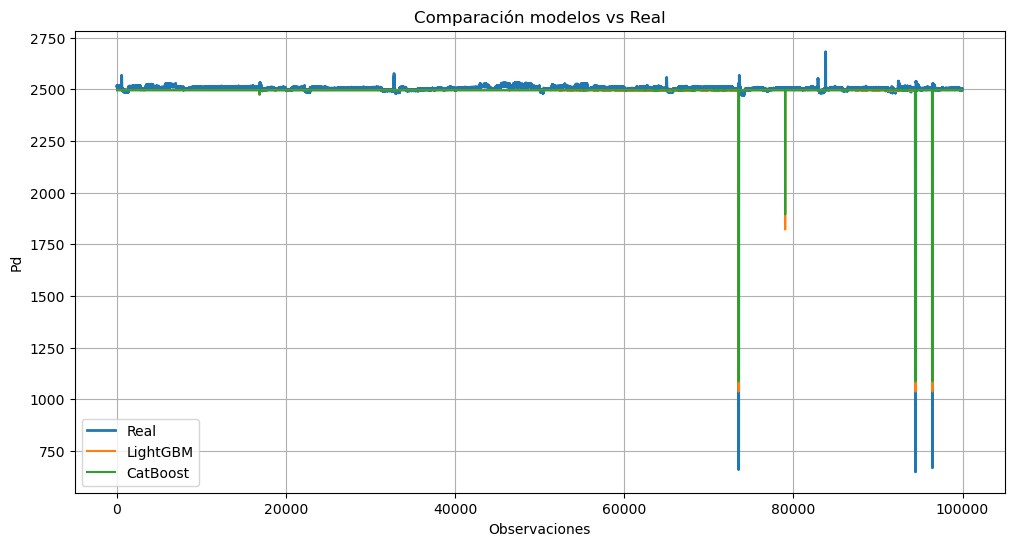

In [20]:
plt.figure(figsize=(12,6))

window_max=100000

plt.plot(y_test.values[:window_max], label='Real', linewidth=2)
#plt.plot(y_pred_lr[:window_max], label='Linear')
#plt.plot(y_pred_rf[:window_max], label='Random Forest')
#plt.plot(y_pred_gbr[:window_max], label='GBR')
#plt.plot(y_pred_xgb[:window_max], label='XGB')
plt.plot(y_pred_lgbm[:window_max], label='LightGBM')
plt.plot(y_pred_cat[:window_max], label='CatBoost')

plt.legend()
plt.title('Comparación modelos vs Real')
plt.xlabel('Observaciones')
plt.ylabel('Pd')
plt.grid(True)

plt.show()

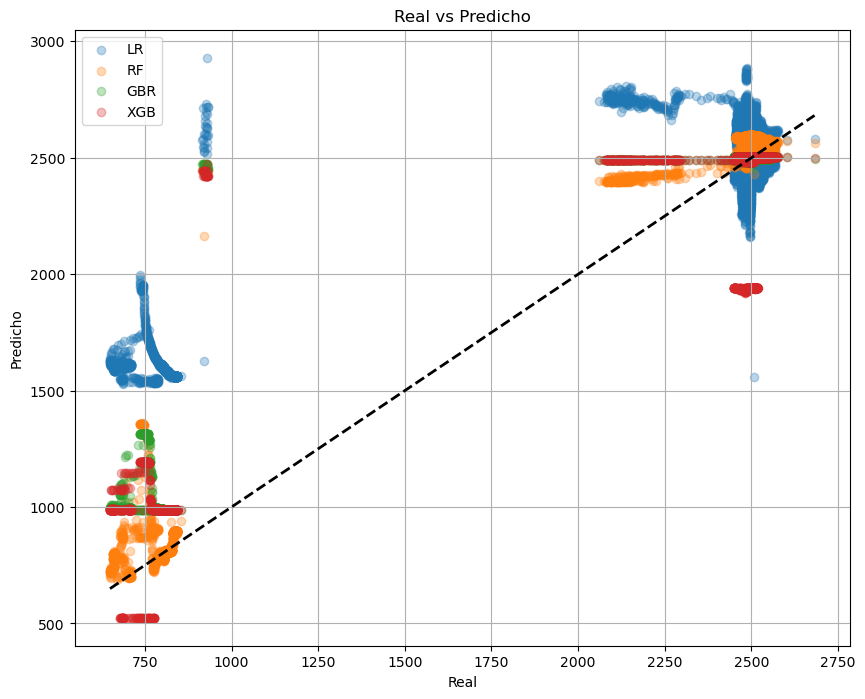

In [86]:
plt.figure(figsize=(10,8))

plt.scatter(y_test, y_pred_lr, alpha=0.3, label='LR')
plt.scatter(y_test, y_pred_rf, alpha=0.3, label='RF')
#plt.scatter(y_test, y_pred_svr, alpha=0.3, label='SVR')
plt.scatter(y_test, y_pred_gbr, alpha=0.3, label='GBR')
plt.scatter(y_test, y_pred_xgb, alpha=0.3, label='XGB')

# Línea ideal
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'k--', linewidth=2)

plt.xlabel('Real')
plt.ylabel('Predicho')
plt.title('Real vs Predicho')
plt.legend()
plt.grid(True)

plt.show()

In [87]:
print("Fecha inicial:", y_test.index.min())
print("Fecha final:", y_test.index.max())

Fecha inicial: 2025-12-06 13:46:33
Fecha final: 2026-04-23 21:42:30


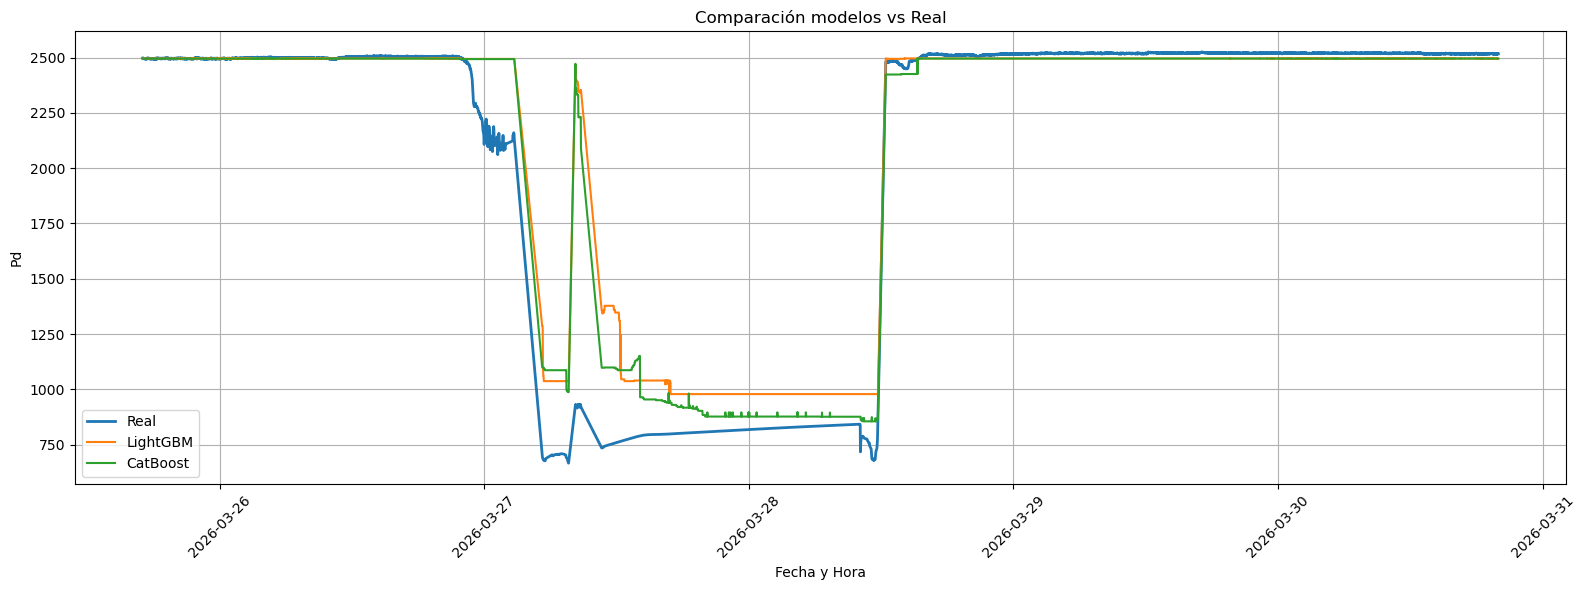

In [22]:
inicio = '2026-03-25 17:00:00'
fin    = '2026-03-30 20:00:00'

mask = (y_test.index >= inicio) & (y_test.index <= fin)

plt.figure(figsize=(16,6))

plt.plot(y_test.index[mask], y_test[mask], label='Real', linewidth=2)
#plt.plot(y_test.index[mask], y_pred_rf[mask], label='Random Forest')
#plt.plot(y_test.index[mask], y_pred_gbr[mask], label='GBR')
#plt.plot(y_test.index[mask], y_pred_xgb[mask], label='XGB')
# plt.plot(y_test.index[mask], y_pred_lr[mask], label='Linear')
plt.plot(y_test.index[mask], y_pred_lgbm[mask], label='LightGBM')
plt.plot(y_test.index[mask], y_pred_cat[mask], label='CatBoost')




plt.legend()
plt.title('Comparación modelos vs Real')
plt.xlabel('Fecha y Hora')
plt.ylabel('Pd')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Revision cruzada

In [57]:
# =====================================================
# VALIDACIÓN CRUZADA TEMPORAL Random Forest
# =====================================================

tscv = TimeSeriesSplit(n_splits=5)

results = []

fold = 1

for train_index, test_index in tscv.split(X):

    # división temporal
    X_train = X.iloc[train_index]
    X_test = X.iloc[test_index]

    y_train = y.iloc[train_index]
    y_test = y.iloc[test_index]

    # =================================================
    # MODELO RANDOM FOREST
    # =================================================

    #model = RandomForestRegressor(n_estimators=100, random_state=42)
    model = RandomForestRegressor(
    n_estimators=200,
    min_samples_split=2,
    min_samples_leaf=2,
    max_features='sqrt',
    max_depth=20,
    random_state=42,
    n_jobs=-1
    )
    # entrenamiento
    model.fit(X_train, y_train)

    # predicción
    y_pred = model.predict(X_test)

    # =================================================
    # MÉTRICAS
    # =================================================

    mae = mean_absolute_error(y_test, y_pred)

    rmse = np.sqrt(
        mean_squared_error(y_test, y_pred)
    )

    r2 = r2_score(y_test, y_pred)

    # fechas del fold
    train_dates = X_train.index
    test_dates = X_test.index

    # guardar resultados
    results.append({
        'Fold': fold,

        'Train Start': train_dates.min(),
        'Train End': train_dates.max(),

        'Test Start': test_dates.min(),
        'Test End': test_dates.max(),

        'Train Size': len(train_index),
        'Test Size': len(test_index),

        'MAE': mae,
        'RMSE': rmse,
        'R2': r2
    })

    # =================================================
    # IMPRESIÓN
    # =================================================

    print("\n" + "="*60)

    print(f"FOLD {fold}")

    print("-"*60)

    print(f"TRAIN:")
    print(f"Inicio: {train_dates.min()}")
    print(f"Fin   : {train_dates.max()}")
    print(f"Datos : {len(train_index):,}")

    print()

    print(f"TEST:")
    print(f"Inicio: {test_dates.min()}")
    print(f"Fin   : {test_dates.max()}")
    print(f"Datos : {len(test_index):,}")

    print()

    print("MÉTRICAS:")
    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R2   : {r2:.4f}")

    fold += 1

# =====================================================
# RESUMEN FINAL
# =====================================================

results_df = pd.DataFrame(results)

print("\n" + "="*60)
print("RESUMEN VALIDACIÓN CRUZADA")
print("="*60)

print(results_df)

print("\nPROMEDIO MÉTRICAS")

print(
    results_df[['MAE', 'RMSE', 'R2']].mean()
)


FOLD 1
------------------------------------------------------------
TRAIN:
Inicio: 2024-01-01 01:00:30
Fin   : 2024-06-06 02:10:30
Datos : 153,790

TEST:
Inicio: 2024-06-06 02:11:30
Fin   : 2024-10-03 15:52:30
Datos : 153,785

MÉTRICAS:
MAE  : 2.2068
RMSE : 3.2549
R2   : 0.9949

FOLD 2
------------------------------------------------------------
TRAIN:
Inicio: 2024-01-01 01:00:30
Fin   : 2024-10-03 15:52:30
Datos : 307,575

TEST:
Inicio: 2024-10-03 15:53:34
Fin   : 2025-02-03 03:00:30
Datos : 153,785

MÉTRICAS:
MAE  : 210.8176
RMSE : 240.4625
R2   : -24.1964

FOLD 3
------------------------------------------------------------
TRAIN:
Inicio: 2024-01-01 01:00:30
Fin   : 2025-02-03 03:00:30
Datos : 461,360

TEST:
Inicio: 2025-02-03 03:01:30
Fin   : 2025-09-08 11:26:31
Datos : 153,785

MÉTRICAS:
MAE  : 3.4752
RMSE : 18.3396
R2   : 0.9873

FOLD 4
------------------------------------------------------------
TRAIN:
Inicio: 2024-01-01 01:00:30
Fin   : 2025-09-08 11:26:31
Datos : 615,145

TEST

# Hyperpareter tunning

## Random forest Hypertunning

In [31]:
tscv = TimeSeriesSplit(n_splits=5)

param_dist = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt']
}

rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

In [32]:
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=10,                      # número de combinaciones aleatorias
    cv=tscv,                        # validación temporal
    scoring='neg_root_mean_squared_error',
    verbose=2,
    random_state=42,
    n_jobs=-1
)

In [33]:
# Ejecutar búsqueda aleatoria
random_search.fit(X_train, y_train)
print("\nMejores parámetros encontrados:\n")
print(random_search.best_params_)
best_rf = random_search.best_estimator_

Fitting 5 folds for each of 10 candidates, totalling 50 fits

Mejores parámetros encontrados:

{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 20}


In [34]:
# Evaluar modelo afinado
y_pred_rf = best_rf.predict(X_test)
evaluar(y_test, y_pred_rf, "Random Forest Tuned")

Random Forest Tuned -> RMSE: 56.984 | R2: 0.908


## Gradient boosting hypertunning

In [37]:
tscv = TimeSeriesSplit(n_splits=5)
gbr = GradientBoostingRegressor(
    random_state=42
)
param_dist = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'subsample': [0.7, 0.8, 1.0],
    'max_features': ['sqrt', None]
}

In [38]:
random_search_gbr = RandomizedSearchCV(
    estimator=gbr,
    param_distributions=param_dist,
    n_iter=10,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    verbose=2,
    random_state=42,
    n_jobs=-1
)

In [39]:
random_search_gbr.fit(X_train, y_train)
print("\nMejores parámetros encontrados:\n")
print(random_search_gbr.best_params_)
best_gbr = random_search_gbr.best_estimator_

Fitting 5 folds for each of 10 candidates, totalling 50 fits

Mejores parámetros encontrados:

{'subsample': 0.8, 'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': 3, 'learning_rate': 0.01}


In [40]:
y_pred_gbr = best_gbr.predict(X_test)
evaluar(y_test, y_pred_gbr, "Gradient Boosting Tuned")

Gradient Boosting Tuned -> RMSE: 57.987 | R2: 0.916


## XGBRegresorr hypertuning

In [52]:
tscv = TimeSeriesSplit(n_splits=5)
xgb = XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)
param_dist = {
    'n_estimators': [100, 200, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1, 0.3],
    'reg_alpha': [0, 0.01, 0.1],
    'reg_lambda': [1, 1.5, 2]
}

In [53]:
random_search_xgb = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=10,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    verbose=2,
    random_state=42,
    n_jobs=-1
)

In [54]:
random_search_xgb.fit(X_train, y_train)
print("\nMejores parámetros encontrados:\n")
print(random_search_xgb.best_params_)
best_xgb = random_search_xgb.best_estimator_

Fitting 5 folds for each of 10 candidates, totalling 50 fits

Mejores parámetros encontrados:

{'subsample': 0.8, 'reg_lambda': 2, 'reg_alpha': 0.1, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.01, 'gamma': 0.3, 'colsample_bytree': 0.7}


In [55]:
y_pred_xgb = best_xgb.predict(X_test)
evaluar(y_test, y_pred_xgb, "XGBoost Tuned")

XGBoost Tuned -> RMSE: 55.269 | R2: 0.910
